In [ ]:
Завдання 1. Класифікація змінних

Місто — номінальна шкала. Міста є категоріями, між якими немає природного порядку. Для міста коректною мірою положення є лише мода.

Номер місяця — порядкова шкала (обраний підхід). Місяці мають природний календарний порядок, але нульового місяця не існує. Крім того, календарний цикл повторюється після грудня. Тому в цьому дослідженні розглядаємо номер місяця як порядкову змінну. Для неї коректними є медіана та мода. Водночас можна аргументувати інтервальну шкалу через рівні календарні проміжки, але це не робить обчислення середнього номера місяця змістовним у всіх випадках.

Кількість опадів — відносна шкала. Має природний нуль (відсутність опадів), а співвідношення значень має зміст. Для цієї змінної коректні середнє, медіана та мода.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rain = pd.Series(
    [37, 34, 31, 37, 48, 62, 68, 52, 38, 34, 39, 41],
    index=["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
           "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]
)

variation = np.sort(rain.values)
print("Варіаційний ряд:", variation)

bins = [30, 40, 50, 60, 70]
labels = ["30–39", "40–49", "50–59", "60–69"]

groups = pd.cut(
    rain,
    bins=bins,
    labels=labels,
    right=False
)

freq = groups.value_counts().sort_index()
rel = (freq / len(rain) * 100).round(1)
cum = freq.cumsum()

table = pd.DataFrame({
    "Абсолютна частота": freq,
    "Відносна частота (%)": rel,
    "Накопичена частота": cum
})

print(table)

Варіаційний ряд: [31 34 34 37 37 38 39 41 48 52 62 68]
       Абсолютна частота  Відносна частота (%)  Накопичена частота
30–39                  7                  58.3                   7
40–49                  2                  16.7                   9
50–59                  1                   8.3                  10
60–69                  2                  16.7                  12


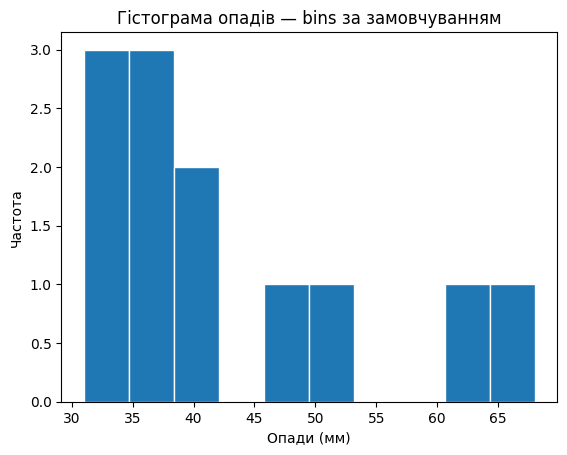

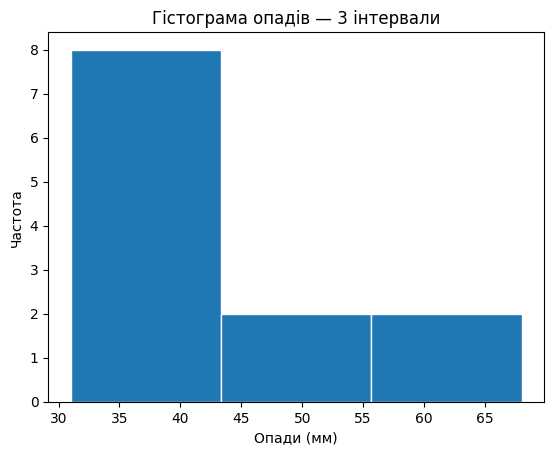

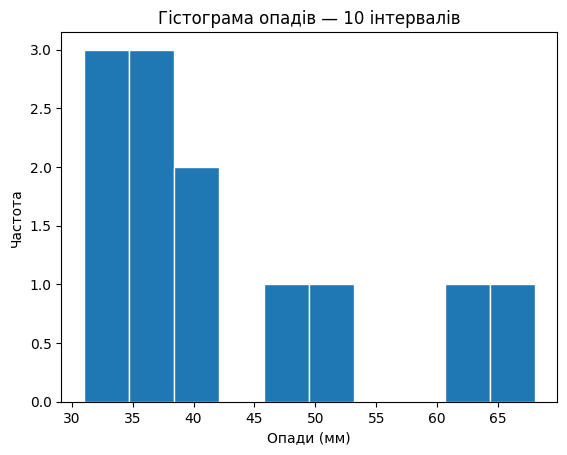

Правило sqrt(n): 3.4641016151377544
Правило Стерджеса: 4.584962500721156


In [2]:
plt.hist(rain, edgecolor="white")
plt.title("Гістограма опадів — bins за замовчуванням")
plt.xlabel("Опади (мм)")
plt.ylabel("Частота")
plt.show()

plt.hist(rain, bins=3, edgecolor="white")
plt.title("Гістограма опадів — 3 інтервали")
plt.xlabel("Опади (мм)")
plt.ylabel("Частота")
plt.show()

plt.hist(rain, bins=10, edgecolor="white")
plt.title("Гістограма опадів — 10 інтервалів")
plt.xlabel("Опади (мм)")
plt.ylabel("Частота")
plt.show()

n = len(rain)

print("Правило sqrt(n):", np.sqrt(n))
print("Правило Стерджеса:", 1 + np.log2(n))

In [3]:
print("Середнє:", rain.mean())
print("Медіана:", rain.median())
print("Мода:", rain.mode().tolist())

print("Q1:", rain.quantile(0.25))
print("Q3:", rain.quantile(0.75))

Середнє: 43.416666666666664
Медіана: 38.5
Мода: [34, 37]
Q1: 36.25
Q3: 49.0


In [ ]:
Завдання 5.
Кількість опадів належить до відносної шкали, оскільки має природний нуль та дозволяє порівнювати значення за допомогою арифметичних операцій. Тому для неї можна коректно використовувати середнє, медіану та моду.

Місто належить до номінальної шкали. Навіть якщо закодувати міста числами, ці числа будуть лише умовними позначеннями. Обчислення середнього або медіани таких кодів не матиме змістовного статистичного тлумачення. Для міста використовується мода.

In [ ]:
Контрольні питання

1. Чому середнє арифметичне некоректне для змінної «місто»?

Місто є номінальною категорією без числового порядку. Присвоєння числових кодів не створює реальних кількісних значень, тому середнє арифметичне таких кодів не має змістовного значення.

2. Чому номер місяця має неоднозначну класифікацію?

Місяці мають природний порядок і рівні календарні проміжки між сусідніми місяцями. Однак нульового місяця не існує, а календарний цикл повторюється. Через це номер місяця можна розглядати як порядкову змінну або обґрунтовувати інтервальну класифікацію, залежно від мети дослідження.

3. Чому для опадів потрібна гістограма, а не стовпчикова діаграма за окремими значеннями?

Кількість опадів є кількісною змінною, а значення можуть бути різними. Гістограма об'єднує їх в інтервали та допомагає побачити форму розподілу. Стовпчикова діаграма за кожним окремим значенням при невеликому наборі може бути менш інформативною.

4. Що означає накопичена частота на межі третього інтервалу?

Накопичена частота 10 на межі третього інтервалу означає, що 10 із 12 місяців мають кількість опадів від 30 до 59 мм. Це становить 83,3% усіх місяців року.